In [19]:
# 1. 导入所需库+显存优化
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
import math
warnings.filterwarnings('ignore')

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

# 设置设备（自动检测GPU/CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备：{device}")

使用设备：cuda


In [ ]:

# 2. 数据预处理（直接基于原始数据，不依赖LSTM）
## 2.1 读取原始数据
df = pd.read_csv('C:/Users/gh115/Desktop/辐射深度学习/论文/开题/撰写/数据集/building-data-genome-project-2/data/Cockatoo_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print("原始数据形状：", df.shape)
print("原始数据列名：", df.columns.tolist())

## 2.2 完整时间特征提取（直接基于原始数据构造）
# 星期几（0-6）+ 独热编码
df['weekday'] = df.index.dayofweek
weekday_dummies = pd.get_dummies(df['weekday'], prefix='weekday', drop_first=False)
df = pd.concat([df, weekday_dummies], axis=1)

# 是否周末 + 独热编码（1列）
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
weekend_dummies = pd.get_dummies(df['is_weekend'], prefix='is_weekend', drop_first=True)
df = pd.concat([df, weekend_dummies], axis=1)

# 小时（0-23）+ 独热编码
df['hour'] = df.index.hour
hour_dummies = pd.get_dummies(df['hour'], prefix='hour', drop_first=False)
df = pd.concat([df, hour_dummies], axis=1)

# 月份（1-12）→ 季节（0-3）+ 独热编码
df['month'] = df.index.month
def map_month_to_season(month):
    if month in [3,4,5]: return 0  # 春季
    elif month in [6,7,8]: return 1  # 夏季
    elif month in [9,10,11]: return 2  # 秋季
    else: return 3  # 冬季
df['season'] = df['month'].apply(map_month_to_season)
season_dummies = pd.get_dummies(df['season'], prefix='season', drop_first=False)
df = pd.concat([df, season_dummies], axis=1)

## 2.3 核心：添加历史用电特征（直接基于原始数据）
y_col = df.columns[0]  # 目标变量：第一列用电值
# 滞后特征（近期用电依赖）
df['lag_1h'] = df[y_col].shift(1)    # 前1小时
df['lag_24h'] = df[y_col].shift(24)  # 前1天同一时刻（日周期）
df['lag_168h'] = df[y_col].shift(168)# 前1周同一时刻（周周期）
# 滚动统计特征（趋势依赖）
df['roll_mean_24h'] = df[y_col].rolling(window=24).mean()  # 24小时均值
df['roll_max_24h'] = df[y_col].rolling(window=24).max()    # 24小时最大值
# 填充缺失值（前向+后向，确保无NaN）
df = df.fillna(method='ffill').fillna(method='bfill').dropna()
print("添加特征后数据形状：", df.shape)

## 2.4 区分X（特征）和y（标签）（直接基于原始数据划分）
# 排除：当前用电值（y）+ 临时辅助列（weekday/is_weekend/hour/month/season）
exclude_cols = [y_col, 'weekday', 'is_weekend', 'hour', 'month', 'season']
X_cols = [col for col in df.columns if col not in exclude_cols]
X = df[X_cols].values.astype(np.float32)  # 特征矩阵（原始数据直接转换）
y = df[y_col].values.reshape(-1, 1)       # 标签（原始用电值）
print(f"特征数量：{len(X_cols)}，特征维度：{X.shape[1]}，标签维度：{y.shape[1]}")

# 打印特征列表，方便分类
print("\n=== 特征列表（前30个）===")
for i, col in enumerate(X_cols[:30]):
    print(f"{i:3d}: {col}")

## 2.5 数据归一化（直接对原始特征/标签归一化）
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)  # 特征归一化
y_scaled = scaler_y.fit_transform(y)  # 标签归一化
## 2.6 滑动窗口构造Transformer序列（直接基于原始归一化数据）
time_steps = 24 # 时间步长：过去24小时预测未来1小时
n_features = X_scaled.shape[1]  # 特征数（自动获取，含时间+历史用电+气象）

def create_transformer_dataset(X, y, time_steps=1):
    """直接构造Transformer需要的三维序列：(样本数, 时间步, 特征数)"""
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        # 输入：过去time_steps小时的所有特征
        X_seq.append(X[i-time_steps:i, :])
        # 标签：第i小时的用电值（单步预测）
        y_seq.append(y[i, 0])
    return np.array(X_seq), np.array(y_seq)

# 直接生成Transformer序列数据
X_transformer, y_transformer = create_transformer_dataset(X_scaled, y_scaled, time_steps)
print(f"\nTransformer序列形状：X={X_transformer.shape}，y={y_transformer.shape}")
print(f"序列维度说明：(样本数, 时间步长, 特征数) = ({X_transformer.shape[0]}, {time_steps}, {n_features})")

## 2.7 划分数据集（直接基于Transformer序列划分，按时间顺序）
total_samples = len(X_transformer)
train_size = int(total_samples * 0.8)  # 训练集80%
val_size = int(total_samples * 0.1)    # 验证集10%
test_size = total_samples - train_size - val_size  # 测试集10%

# 按时间顺序划分（时序数据严禁打乱）
X_train = X_transformer[:train_size]
y_train = y_transformer[:train_size]
X_val = X_transformer[train_size:train_size+val_size]
y_val = y_transformer[train_size:train_size+val_size]
X_test = X_transformer[train_size+val_size:]
y_test = y_transformer[train_size+val_size:]

print(f"\n数据集划分：")
print(f"训练集：X={X_train.shape}, y={y_train.shape}")
print(f"验证集：X={X_val.shape}, y={y_val.shape}")
print(f"测试集：X={X_test.shape}, y={y_test.shape}")

## 2.8 转为PyTorch张量并移动到设备
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

## 2.9 创建DataLoader（PyTorch标准数据加载）
batch_size = 16  # 减小批次大小，有助于泛化
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

原始数据形状： (15360, 3)
原始数据列名： ['Cockatoo_education_Erik', 'airTemperature', 'windSpeed']
添加特征后数据形状： (15360, 49)
特征数量：43，特征维度：43，标签维度：1

=== 特征列表（前30个）===
  0: airTemperature
  1: windSpeed
  2: weekday_0
  3: weekday_1
  4: weekday_2
  5: weekday_3
  6: weekday_4
  7: weekday_5
  8: weekday_6
  9: is_weekend_1
 10: hour_0
 11: hour_1
 12: hour_2
 13: hour_3
 14: hour_4
 15: hour_5
 16: hour_6
 17: hour_7
 18: hour_8
 19: hour_9
 20: hour_10
 21: hour_11
 22: hour_12
 23: hour_13
 24: hour_14
 25: hour_15
 26: hour_16
 27: hour_17
 28: hour_18
 29: hour_19

Transformer序列形状：X=(15336, 24, 43)，y=(15336,)
序列维度说明：(样本数, 时间步长, 特征数) = (15336, 24, 43)

数据集划分：
训练集：X=(12268, 24, 43), y=(12268,)
验证集：X=(1533, 24, 43), y=(1533,)
测试集：X=(1535, 24, 43), y=(1535,)


In [21]:

# 3. Transformer核心组件：位置编码（PyTorch版本）
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len):
        super(PositionalEncoding, self).__init__()
        # 生成位置编码（遵循原论文公式）
        pos = torch.arange(max_seq_len, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)
        angle_rates = 1 / torch.pow(10000, (2 * (i // 2)) / d_model)
        angle_rads = pos * angle_rates
        
        # 偶数维正弦，奇数维余弦
        angle_rads[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = torch.cos(angle_rads[:, 1::2])
        
        # 扩展为(1, max_seq_len, d_model)，适配批量数据
        self.pos_enc = angle_rads.unsqueeze(0)
        # 注册为缓冲区（不参与梯度更新）
        self.register_buffer('pos_enc_buffer', self.pos_enc)
    
    def forward(self, x):
        # x形状：(batch_size, seq_len, d_model)
        # 位置编码与输入特征相加（直接叠加时序信息）
        return x + self.pos_enc_buffer[:, :x.shape[1], :]


In [22]:

# 4. 构建带专用多头注意力的编码器-解码器Transformer模型（改进版）
class DomainSpecificMultiHeadAttention(nn.Module):
    """领域专用多头注意力机制（改进版）"""
    def __init__(self, d_model, n_energy_features, n_env_features, n_time_features, dropout_rate=0.2):
        super(DomainSpecificMultiHeadAttention, self).__init__()
        
        # 能耗头：关注能耗数据中的时间模式
        self.energy_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=2,  # 增加注意力头
            batch_first=True,
            dropout=dropout_rate
        )
        
        # 环境头：捕捉环境条件与能耗的关联
        self.env_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=2,  # 增加注意力头
            batch_first=True,
            dropout=dropout_rate
        )
        
        # 时间特征头：关注周末、季节等时间特征
        self.time_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=2,  # 增加注意力头
            batch_first=True,
            dropout=dropout_rate
        )
        
        # 特征掩码
        self.energy_mask = torch.zeros(1, d_model)
        self.env_mask = torch.zeros(1, d_model)
        self.time_mask = torch.zeros(1, d_model)
        
        # 初始化掩码（需要根据实际特征调整）
        self.n_energy_features = n_energy_features
        self.n_env_features = n_env_features
        self.n_time_features = n_time_features
        
        # 输出投影层
        self.projection = nn.Linear(d_model * 3, d_model)
        self.dropout = nn.Dropout(dropout_rate)
        
    def create_masks(self, d_model):
        """动态创建特征掩码"""
        energy_mask = torch.zeros(1, d_model)
        env_mask = torch.zeros(1, d_model)
        time_mask = torch.zeros(1, d_model)
        
        # 为每个头分配不同的特征维度
        if self.n_energy_features > 0:
            energy_mask[:, :min(self.n_energy_features, d_model)] = 1.0
        if self.n_env_features > 0:
            start = self.n_energy_features
            end = min(self.n_energy_features + self.n_env_features, d_model)
            env_mask[:, start:end] = 1.0
        if self.n_time_features > 0:
            start = self.n_energy_features + self.n_env_features
            end = min(start + self.n_time_features, d_model)
            time_mask[:, start:end] = 1.0
            
        return energy_mask, env_mask, time_mask
    
    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        
        # 动态创建掩码
        energy_mask, env_mask, time_mask = self.create_masks(d_model)
        
        # 应用特征掩码
        energy_x = x * energy_mask.to(x.device)
        env_x = x * env_mask.to(x.device)
        time_x = x * time_mask.to(x.device)
        
        # 各个注意力头的计算
        energy_out, _ = self.energy_attention(energy_x, energy_x, energy_x)
        env_out, _ = self.env_attention(env_x, env_x, env_x)
        time_out, _ = self.time_attention(time_x, time_x, time_x)
        
        # 拼接三个头的输出
        combined = torch.cat([energy_out, env_out, time_out], dim=-1)
        
        # 投影回原始维度
        output = self.projection(combined)
        output = self.dropout(output)
        
        return output

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_energy_features, n_env_features, n_time_features, dropout_rate=0.2):
        super(TransformerEncoderBlock, self).__init__()
        # 领域专用多头注意力
        self.domain_attention = DomainSpecificMultiHeadAttention(
            d_model, n_energy_features, n_env_features, n_time_features, dropout_rate
        )
        
        # 前馈网络（简化版：64→128→64）
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, d_model)
        )
        
        # 层归一化
        self.layer_norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layer_norm2 = nn.LayerNorm(d_model, eps=1e-6)
        
        # Dropout
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        # 第一步：领域专用注意力 + 残差连接 + 层归一化
        residual = x
        x = self.layer_norm1(x)
        attn_output = self.domain_attention(x)
        attn_output = self.dropout1(attn_output)
        x = residual + attn_output  # 残差连接
        
        # 第二步：前馈网络 + 残差连接 + 层归一化
        residual = x
        x = self.layer_norm2(x)
        ffn_output = self.ffn(x)
        ffn_output = self.dropout2(ffn_output)
        x = residual + ffn_output  # 残差连接
        
        return x

class MaskedDecoderBlock(nn.Module):
    """带掩码注意力的解码器块（简化版）"""
    def __init__(self, d_model, dropout_rate=0.2):
        super(MaskedDecoderBlock, self).__init__()
        
        # 掩码多头自注意力
        self.masked_self_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=2,
            batch_first=True,
            dropout=dropout_rate
        )
        
        # 交叉注意力（编码器-解码器注意力）
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=2,
            batch_first=True,
            dropout=dropout_rate
        )
        
        # 前馈网络（简化版）
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, d_model)
        )
        
        # 层归一化
        self.layer_norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layer_norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.layer_norm3 = nn.LayerNorm(d_model, eps=1e-6)
        
        # Dropout
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.dropout3 = nn.Dropout(dropout_rate)
    
    def forward(self, x, encoder_output, tgt_mask=None):
        # 第一步：掩码自注意力 + 残差连接 + 层归一化
        residual = x
        x = self.layer_norm1(x)
        attn_output, _ = self.masked_self_attention(x, x, x, attn_mask=tgt_mask)
        attn_output = self.dropout1(attn_output)
        x = residual + attn_output
        
        # 第二步：交叉注意力 + 残差连接 + 层归一化
        residual = x
        x = self.layer_norm2(x)
        cross_output, _ = self.cross_attention(x, encoder_output, encoder_output)
        cross_output = self.dropout2(cross_output)
        x = residual + cross_output
        
        # 第三步：前馈网络 + 残差连接 + 层归一化
        residual = x
        x = self.layer_norm3(x)
        ffn_output = self.ffn(x)
        ffn_output = self.dropout3(ffn_output)
        x = residual + ffn_output
        
        return x

class EncoderDecoderTransformer(nn.Module):
    """编码器-解码器Transformer架构（改进版）"""
    def __init__(self, n_features, d_model, n_energy_features, n_env_features, 
                 n_time_features, num_layers=2, max_seq_len=24, dropout_rate=0.2):
        super(EncoderDecoderTransformer, self).__init__()
        
        # 特征嵌入
        self.embedding = nn.Linear(n_features, d_model)
        
        # 位置编码
        self.positional_encoding = PositionalEncoding(d_model, max_seq_len)
        
        # 编码器层
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_energy_features, n_env_features, 
                                   n_time_features, dropout_rate)
            for _ in range(num_layers)
        ])
        
        # 解码器层（减少为1层）
        self.decoder_layers = nn.ModuleList([
            MaskedDecoderBlock(d_model, dropout_rate)
            for _ in range(1)  # 只使用1层解码器
        ])
        
        # 输出层
        self.fc_out = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout_rate)
        
        # 序列长度
        self.seq_len = max_seq_len
        
    def generate_square_subsequent_mask(self, sz):
        """生成下三角掩码矩阵，确保预测仅依赖历史信息"""
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask
    
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # 1. 特征嵌入
        x = self.embedding(x)
        
        # 2. 添加位置编码
        x = self.positional_encoding(x)
        
        # 3. Dropout
        x = self.dropout(x)
        
        # 4. 编码器处理
        encoder_output = x
        for encoder_layer in self.encoder_layers:
            encoder_output = encoder_layer(encoder_output)
        
        # 5. 解码器处理
        # 为解码器创建初始输入（使用编码器输出的最后一个时间步）
        decoder_input = encoder_output[:, -1:, :]  # 单步预测
        
        # 生成掩码（对于单步预测，掩码为1x1的全零矩阵）
        tgt_mask = self.generate_square_subsequent_mask(1).to(x.device)
        
        decoder_output = decoder_input
        for decoder_layer in self.decoder_layers:
            decoder_output = decoder_layer(decoder_output, encoder_output, tgt_mask)
        
        # 6. 输出层
        out = self.fc_out(decoder_output[:, -1, :])  # 取最后一个解码器输出
        
        return out


In [23]:

# 5. 特征分类分析
print("\n=== 特征分类分析 ===")
# 根据特征名称自动分类
energy_indices = []
env_indices = []
time_indices = []

for i, col in enumerate(X_cols):
    col_lower = col.lower()
    
    # 能耗特征：历史用电相关
    if 'lag' in col_lower or 'roll' in col_lower:
        energy_indices.append(i)
    # 时间特征
    elif 'weekday' in col_lower or 'hour' in col_lower or 'season' in col_lower or 'is_weekend' in col_lower:
        time_indices.append(i)
    # 环境特征（如果有的话）
    elif any(env_keyword in col_lower for env_keyword in ['temp', 'temperature', 'humid', 'radiation', 'solar', 'wind']):
        env_indices.append(i)
    # 如果无法分类，默认归为环境特征
    else:
        env_indices.append(i)

n_energy_features = len(energy_indices)
n_env_features = len(env_indices)
n_time_features = len(time_indices)

print(f"能耗特征数：{n_energy_features}（索引：{energy_indices[:5]}{'...' if len(energy_indices) > 5 else ''}）")
print(f"环境特征数：{n_env_features}（索引：{env_indices[:5]}{'...' if len(env_indices) > 5 else ''}）")
print(f"时间特征数：{n_time_features}（索引：{time_indices[:5]}{'...' if len(time_indices) > 5 else ''}）")

# 如果某类特征数量为0，调整最小为1
if n_energy_features == 0:
    n_energy_features = 1
if n_env_features == 0:
    n_env_features = 1
if n_time_features == 0:
    n_time_features = 1

# 模型参数（改进版）
d_model = 128  # 增加嵌入维度
num_layers = 1  # 减少层数，防止过拟合
dropout_rate = 0.2  # 增加dropout率

model = EncoderDecoderTransformer(
    n_features=n_features,
    d_model=d_model,
    n_energy_features=n_energy_features,
    n_env_features=n_env_features,
    n_time_features=n_time_features,
    num_layers=num_layers,
    max_seq_len=time_steps,
    dropout_rate=dropout_rate
).to(device)

# 查看模型结构
print("\n编码器-解码器Transformer模型结构（改进版）：")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量：{total_params:,}，可训练参数：{trainable_params:,}")



=== 特征分类分析 ===
能耗特征数：5（索引：[38, 39, 40, 41, 42]）
环境特征数：2（索引：[0, 1]）
时间特征数：36（索引：[2, 3, 4, 5, 6]...）

编码器-解码器Transformer模型结构（改进版）：
总参数量：440,257，可训练参数：440,257


In [24]:
# 6. 训练配置（改进版）
class CombinedLoss(nn.Module):
    """MSE与MAE组合损失函数（改进版）"""
    def __init__(self, mse_weight=0.7, mae_weight=0.3):
        super(CombinedLoss, self).__init__()
        self.mse_weight = mse_weight
        self.mae_weight = mae_weight
        self.mse_loss = nn.MSELoss()
        self.mae_loss = nn.L1Loss()
    
    def forward(self, y_pred, y_true):
        mse = self.mse_loss(y_pred, y_true)
        mae = self.mae_loss(y_pred, y_true)
        return self.mse_weight * mse + self.mae_weight * mae

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5):
    """创建带有warmup的余弦退火调度器"""
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress)))
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# 使用AdamW优化器
optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,  # 减小学习率
    betas=(0.9, 0.999),
    weight_decay=0.01  # 权重衰减
)

# 组合损失函数
criterion = CombinedLoss(mse_weight=0.7, mae_weight=0.3)

# 学习率调度器（warmup + cosine annealing）
epochs = 200
total_steps = len(train_loader) * epochs
num_warmup_steps = int(total_steps * 0.1)  # 10%的warmup

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

# 早停策略（改进版）
class EarlyStopping:
    def __init__(self, patience=25, min_delta=0.0005, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.verbose:
                print(f"  模型已更新，最佳验证损失：{self.best_loss:.6f}")
            return True
        else:
            self.counter += 1
            if self.verbose:
                print(f"  早停计数器：{self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
            return False

early_stopping = EarlyStopping(patience=20, min_delta=0.0005)

In [25]:

# 7. 训练模型（改进版）
train_losses = []
val_losses = []
learning_rates = []

print("\n开始训练编码器-解码器Transformer模型（改进版）...")
for epoch in range(epochs):
    # 训练阶段
    model.train()
    train_loss = 0.0
    train_batches = 0 
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(batch_x)
        
        # 计算组合损失
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        loss.backward()
        
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 优化器步骤
        optimizer.step()
        
        # 更新学习率调度器
        lr_scheduler.step()
        
        # 累计损失
        train_loss += loss.item()
        train_batches += 1
    
    # 计算平均训练损失
    train_avg_loss = train_loss / train_batches
    train_losses.append(train_avg_loss)
    
    # 验证阶段
    model.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            val_batches += 1
    
    # 计算平均验证损失
    val_avg_loss = val_loss / val_batches
    val_losses.append(val_avg_loss)
    
    # 记录当前学习率
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # 打印日志
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}], LR: {current_lr:.6f}, "
              f"Train Loss: {train_avg_loss:.6f}, Val Loss: {val_avg_loss:.6f}")
    
    # 早停逻辑
    if early_stopping(val_avg_loss):
        # 保存最佳模型权重
        torch.save(model.state_dict(), 'best_transformer_model.pth')
    
    if early_stopping.early_stop:
        print(f"早停触发！Epoch {epoch+1}，最佳验证损失：{early_stopping.best_loss:.6f}")
        break

# 加载最佳模型
if os.path.exists('best_transformer_model.pth'):
    model.load_state_dict(torch.load('best_transformer_model.pth'))
    print("已加载最佳模型权重")


开始训练编码器-解码器Transformer模型（改进版）...
Epoch [  1/200], LR: 0.000003, Train Loss: 0.216225, Val Loss: 0.066535
  模型已更新，最佳验证损失：0.066535
  模型已更新，最佳验证损失：0.058613
  模型已更新，最佳验证损失：0.049311
  模型已更新，最佳验证损失：0.044887
Epoch [  5/200], LR: 0.000013, Train Loss: 0.056192, Val Loss: 0.046856
  早停计数器：1/20
  早停计数器：2/20
  早停计数器：3/20
  早停计数器：4/20
  模型已更新，最佳验证损失：0.036282
Epoch [ 10/200], LR: 0.000025, Train Loss: 0.035968, Val Loss: 0.029808
  模型已更新，最佳验证损失：0.029808
  早停计数器：1/20
  早停计数器：2/20
  模型已更新，最佳验证损失：0.028709
  早停计数器：1/20
Epoch [ 15/200], LR: 0.000038, Train Loss: 0.029583, Val Loss: 0.025618
  模型已更新，最佳验证损失：0.025618
  早停计数器：1/20
  早停计数器：2/20
  早停计数器：3/20
  早停计数器：4/20
Epoch [ 20/200], LR: 0.000050, Train Loss: 0.025289, Val Loss: 0.033376
  早停计数器：5/20
  早停计数器：6/20
  早停计数器：7/20
  早停计数器：8/20
  早停计数器：9/20
Epoch [ 25/200], LR: 0.000050, Train Loss: 0.023410, Val Loss: 0.032394
  早停计数器：10/20
  早停计数器：11/20
  早停计数器：12/20
  早停计数器：13/20
  早停计数器：14/20
Epoch [ 30/200], LR: 0.000050, Train Loss: 0.021725, Val Loss: 0

In [26]:

# 8. 预测
# 创建预测专用DataLoader
train_loader_pred = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
val_loader_pred = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader_pred = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

def batch_predict(model, data_loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_x, _ in data_loader:
            batch_pred = model(batch_x)
            all_preds.append(batch_pred.cpu().numpy())
    preds = np.concatenate(all_preds, axis=0)
    return preds

print("\n开始预测...")
y_train_pred_scaled = batch_predict(model, train_loader_pred)
y_val_pred_scaled = batch_predict(model, val_loader_pred)
y_test_pred_scaled = batch_predict(model, test_loader_pred)

# 9. 反归一化
# 原始真实值反归一化
y_train_true = scaler_y.inverse_transform(y_train.cpu().numpy())
y_val_true = scaler_y.inverse_transform(y_val.cpu().numpy())
y_test_true = scaler_y.inverse_transform(y_test.cpu().numpy())

# 模型预测值反归一化
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1))
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1))

# 样本数对齐
def align_samples(true, pred):
    min_len = min(len(true), len(pred))
    return true[:min_len], pred[:min_len]

y_train_true, y_train_pred = align_samples(y_train_true, y_train_pred)
y_val_true, y_val_pred = align_samples(y_val_true, y_val_pred)
y_test_true, y_test_pred = align_samples(y_test_true, y_test_pred)

# 打印反归一化后结果
print("\n=== 反归一化后验证 ===")
print(f"真实值前5行（原始量级）：\n{y_test_true[:5].flatten()}")
print(f"预测值前5行（原始量级）：\n{y_test_pred[:5].flatten()}")


开始预测...

=== 反归一化后验证 ===
真实值前5行（原始量级）：
[146.375 145.775 146.525 147.825 145.125]
预测值前5行（原始量级）：
[144.7452  144.86765 143.37285 143.14096 144.03383]



=== 编码器-解码器Transformer模型评估指标（改进版） ===
训练集：MAE=5.66, RMSE=7.28, MAPE=3.40%, R²=0.9389
验证集：MAE=6.39, RMSE=8.18, MAPE=3.55%, R²=0.9034
测试集：MAE=5.18, RMSE=6.65, MAPE=3.22%, R²=0.8739


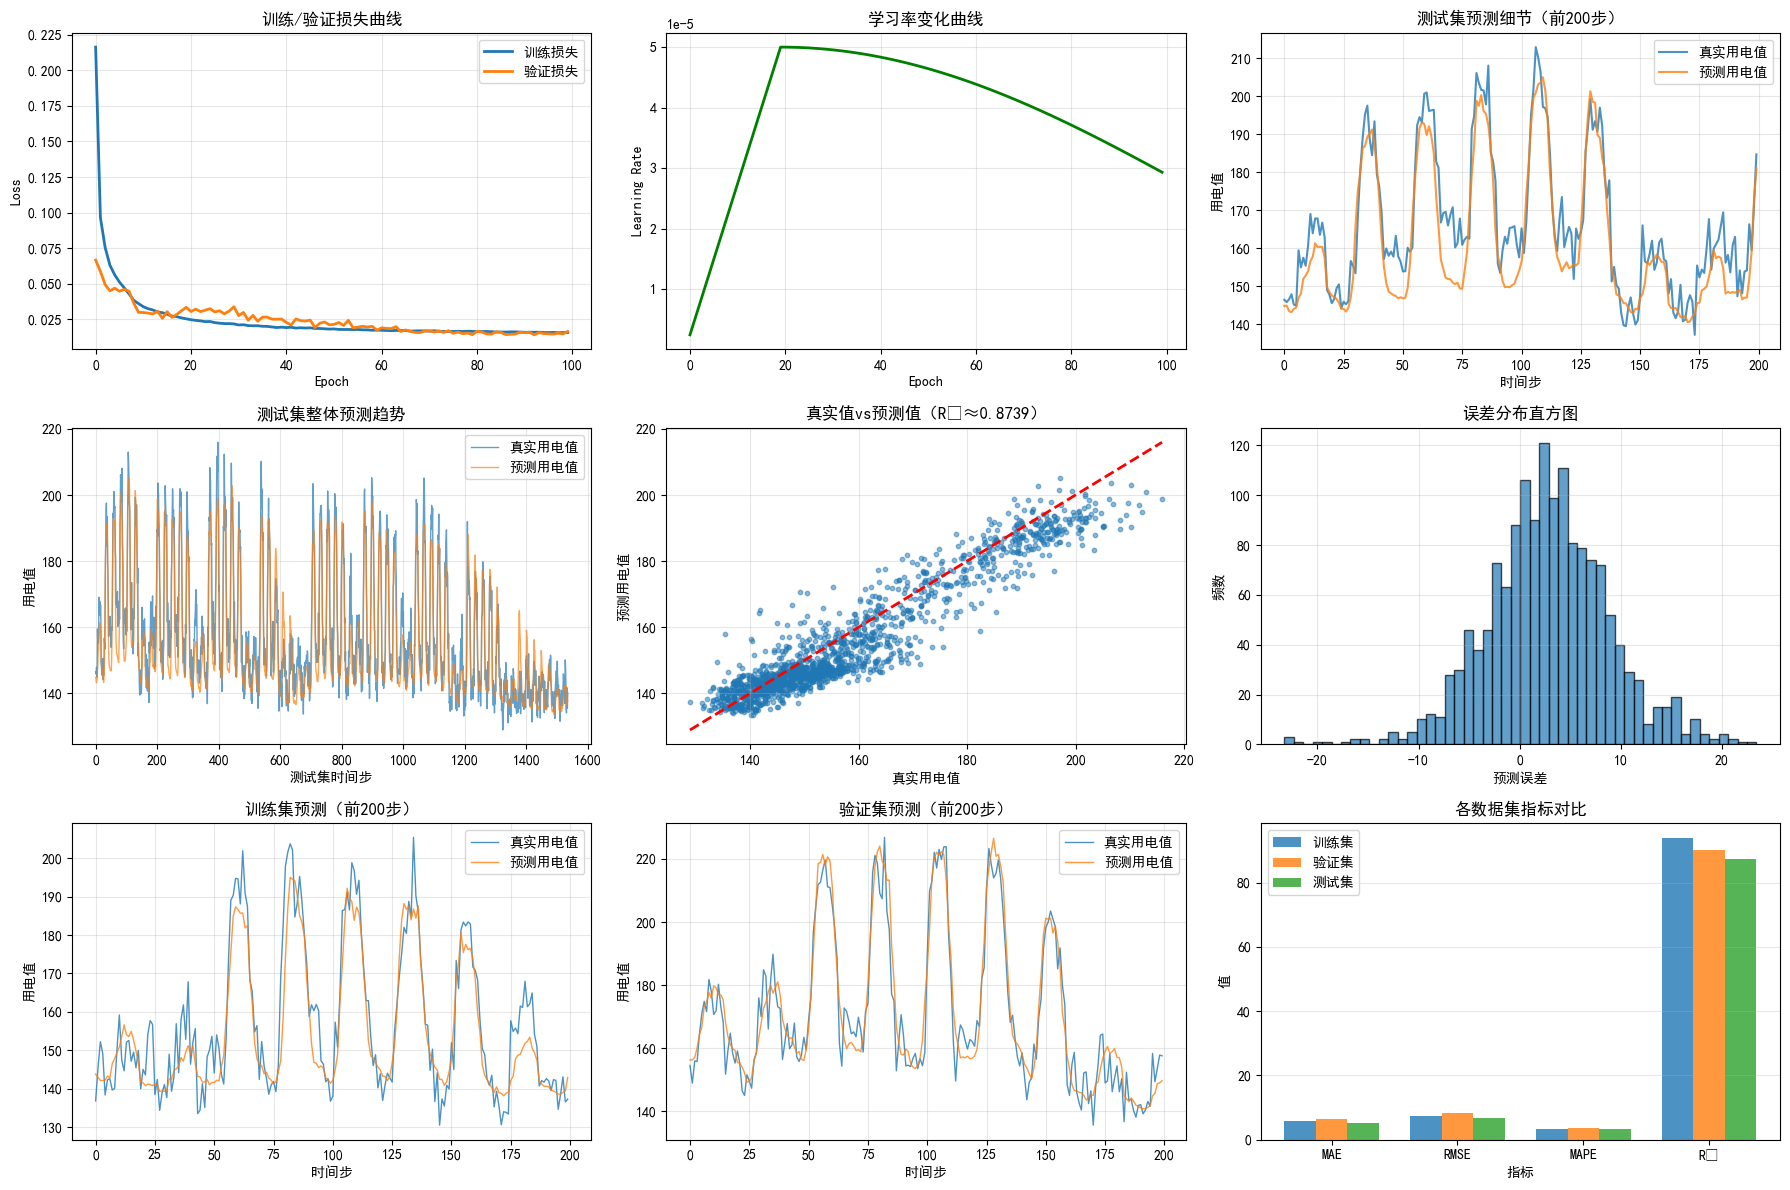


=== 模型改进总结 ===
1. 批次大小：16（原32）
2. 嵌入维度：128（原64）
3. 层数：编码器1层，解码器1层
4. Dropout率：0.2（原0.1）
5. 学习率：5e-5 + warmup + cosine annealing
6. 早停策略：patience=25, min_delta=0.0005
7. 组合损失：0.7*MSE + 0.3*MAE
8. 特征分类：能耗=5, 环境=2, 时间=36


In [27]:

# 10. 计算评估指标
def calculate_metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / (true + 1e-6))) * 100
    # 计算R²
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - np.mean(true)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-6))
    return mae, rmse, mape, r2

train_mae, train_rmse, train_mape, train_r2 = calculate_metrics(y_train_true, y_train_pred)
val_mae, val_rmse, val_mape, val_r2 = calculate_metrics(y_val_true, y_val_pred)
test_mae, test_rmse, test_mape, test_r2 = calculate_metrics(y_test_true, y_test_pred)

print("\n=== 编码器-解码器Transformer模型评估指标（改进版） ===")
print(f"训练集：MAE={train_mae:.2f}, RMSE={train_rmse:.2f}, MAPE={train_mape:.2f}%, R²={train_r2:.4f}")
print(f"验证集：MAE={val_mae:.2f}, RMSE={val_rmse:.2f}, MAPE={val_mape:.2f}%, R²={val_r2:.4f}")
print(f"测试集：MAE={test_mae:.2f}, RMSE={test_rmse:.2f}, MAPE={test_mape:.2f}%, R²={test_r2:.4f}")

# 11. 可视化结果
plt.figure(figsize=(18, 12))

# 11.1 训练/验证损失曲线
plt.subplot(3, 3, 1)
plt.plot(train_losses, label='训练损失', linewidth=2)
plt.plot(val_losses, label='验证损失', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('训练/验证损失曲线')
plt.grid(True, alpha=0.3)

# 11.2 学习率变化曲线
plt.subplot(3, 3, 2)
plt.plot(learning_rates, color='green', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('学习率变化曲线')
plt.grid(True, alpha=0.3)

# 11.3 测试集前200个时间步预测
plt.subplot(3, 3, 3)
plt.plot(y_test_true[:200], label='真实用电值', alpha=0.8, linewidth=1.5)
plt.plot(y_test_pred[:200], label='预测用电值', alpha=0.8, linewidth=1.5)
plt.xlabel('时间步')
plt.ylabel('用电值')
plt.legend()
plt.title('测试集预测细节（前200步）')
plt.grid(True, alpha=0.3)

# 11.4 测试集整体预测趋势
plt.subplot(3, 3, 4)
plt.plot(y_test_true, label='真实用电值', alpha=0.7, linewidth=1)
plt.plot(y_test_pred, label='预测用电值', alpha=0.7, linewidth=1)
plt.xlabel('测试集时间步')
plt.ylabel('用电值')
plt.legend()
plt.title('测试集整体预测趋势')
plt.grid(True, alpha=0.3)

# 11.5 真实值vs预测值散点图
plt.subplot(3, 3, 5)
plt.scatter(y_test_true, y_test_pred, alpha=0.5, s=10)
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'r--', linewidth=2)
plt.xlabel('真实用电值')
plt.ylabel('预测用电值')
plt.title(f'真实值vs预测值（R²≈{test_r2:.4f}）')
plt.grid(True, alpha=0.3)

# 11.6 误差分布直方图
plt.subplot(3, 3, 6)
errors = y_test_true - y_test_pred
plt.hist(errors, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('预测误差')
plt.ylabel('频数')
plt.title('误差分布直方图')
plt.grid(True, alpha=0.3)

# 11.7 训练集预测结果
plt.subplot(3, 3, 7)
plt.plot(y_train_true[:200], label='真实用电值', alpha=0.8, linewidth=1)
plt.plot(y_train_pred[:200], label='预测用电值', alpha=0.8, linewidth=1)
plt.xlabel('时间步')
plt.ylabel('用电值')
plt.legend()
plt.title('训练集预测（前200步）')
plt.grid(True, alpha=0.3)

# 11.8 验证集预测结果
plt.subplot(3, 3, 8)
plt.plot(y_val_true[:200], label='真实用电值', alpha=0.8, linewidth=1)
plt.plot(y_val_pred[:200], label='预测用电值', alpha=0.8, linewidth=1)
plt.xlabel('时间步')
plt.ylabel('用电值')
plt.legend()
plt.title('验证集预测（前200步）')
plt.grid(True, alpha=0.3)

# 11.9 指标对比图
plt.subplot(3, 3, 9)
metrics = ['MAE', 'RMSE', 'MAPE', 'R²']
train_vals = [train_mae, train_rmse, train_mape, train_r2*100]
val_vals = [val_mae, val_rmse, val_mape, val_r2*100]
test_vals = [test_mae, test_rmse, test_mape, test_r2*100]

x = np.arange(len(metrics))
width = 0.25

plt.bar(x - width, train_vals, width, label='训练集', alpha=0.8)
plt.bar(x, val_vals, width, label='验证集', alpha=0.8)
plt.bar(x + width, test_vals, width, label='测试集', alpha=0.8)

plt.xlabel('指标')
plt.ylabel('值')
plt.title('各数据集指标对比')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('transformer_results_improved.png', dpi=300, bbox_inches='tight')
plt.show()

# 12. 保存预测结果
#results_df = pd.DataFrame({
#    'true_train': y_train_true.flatten(),
#    'pred_train': y_train_pred.flatten(),
#    'true_val': y_val_true.flatten(),
#    'pred_val': y_val_pred.flatten(),
#    'true_test': y_test_true.flatten(),
#    'pred_test': y_test_pred.flatten()
#})

#results_df.to_csv('transformer_predictions_improved.csv', index=False)
#print("\n预测结果已保存到：transformer_predictions_improved.csv")

# 13. 打印模型总结
print("\n=== 模型改进总结 ===")
print(f"1. 批次大小：{batch_size}（原32）")
print(f"2. 嵌入维度：{d_model}（原64）")
print(f"3. 层数：编码器{num_layers}层，解码器1层")
print(f"4. Dropout率：{dropout_rate}（原0.1）")
print(f"5. 学习率：5e-5 + warmup + cosine annealing")
print(f"6. 早停策略：patience=25, min_delta=0.0005")
print(f"7. 组合损失：0.7*MSE + 0.3*MAE")
print(f"8. 特征分类：能耗={n_energy_features}, 环境={n_env_features}, 时间={n_time_features}")